---
**BDA03: Tarea de evaluación**
---
Ahora que ya conocemos todo el ecosistema Hadoop-Spark en profundidad, vamos a hacer un ejercico que abarque todo el proceso de tratamiento de los datos: desde que se extraen de un repositorio, se limpian, se trasforman, se exportan a una BD (en este caso relacional) y se realizan consultas sobre ellos.

Para ello:

Recupera los conjuntos de datos que usaste en la tarea anterior BDA01 - Tarea de Evaluación. Recuerda que usaste un conjunto de datos de tu elección de Kaggle https://www.kaggle.com/datasets.

---

# **Explicación del conjunto de datos elegido**
Para la realización de esta tarea hemos elegido un dataset relativo a transacciones financieras.

El conjunto de datos tiene un tamaño de 365 MB (comprimido en ZIP) y de 1,32 GB una vez descomprimido.

Contiene tres ficheros CSV (cards_data.csv, transactions_data.csv y users_data.csv), que se pueden relacionar entre sí mediante el identificador de cliente y el identificador de tarjeta.

Mediante la combinación de los tres listados, podemos obtener información relativa a transacciones bancarias, las tarjetas con las que se realizaron y los usuarios de las mismas.

Puede encontrarse el dataset, así como más información sobre el mismo, en el siguiente enlace: https://www.kaggle.com/datasets/computingvictor/transactions-fraud-datasets

Consideramos que este tipo de conjuntos de datos puede ser interesante, como podemos ver en la URL facilitada, para realizar análisis financieros, detección de fraudes bancarios, tendencias de mercado, etc.

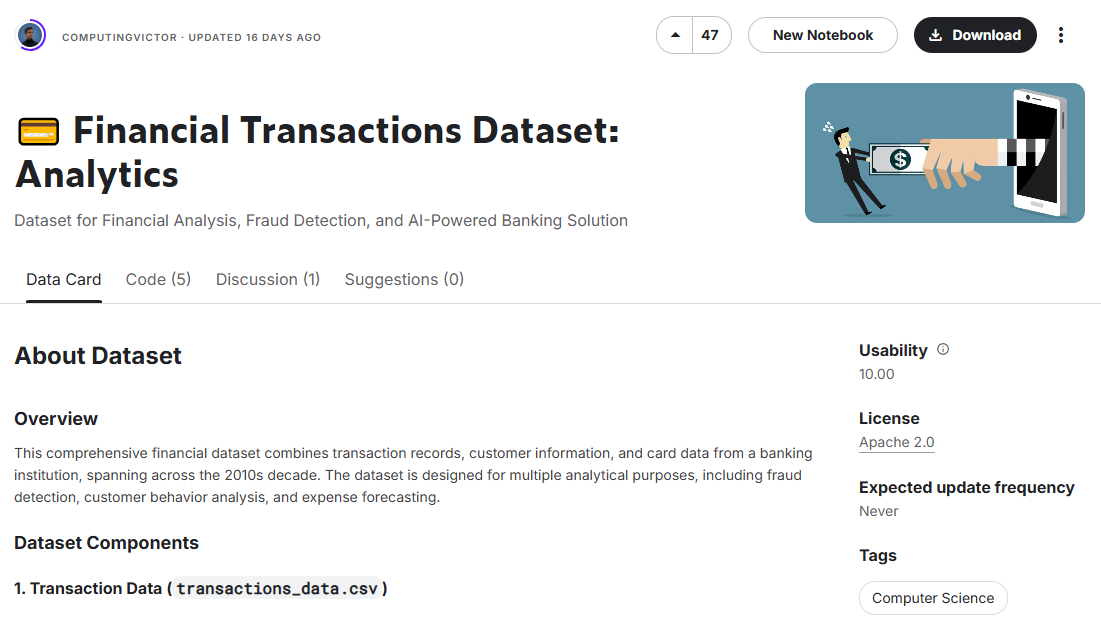



---



#**Instalación de Hadoop y Pig**

In [1]:
import os

# Download and install Hadoop 3.4.2
!wget -q https://downloads.apache.org/hadoop/common/hadoop-3.4.2/hadoop-3.4.2.tar.gz
!tar -xzf hadoop-3.4.2.tar.gz
# Remove destination if it exists to avoid errors or nesting
!rm -rf /usr/local/hadoop-3.4.2
!mv hadoop-3.4.2 /usr/local/
!rm hadoop-3.4.2.tar.gz

# Update environment variables for Java 17 and Hadoop 3.4.2
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["HADOOP_HOME"] = "/usr/local/hadoop-3.4.2"

# Update PATH to include Hadoop bin
if "/usr/local/hadoop-3.4.2/bin" not in os.environ["PATH"]:
    os.environ["PATH"] = os.environ["PATH"] + ":" + "/usr/local/hadoop-3.4.2/bin"

# Verify installations
print("Hadoop Version:")
!hadoop version
print("\nJava Version:")
!java -version

Hadoop Version:
Hadoop 3.4.2
Source code repository https://github.com/apache/hadoop.git -r 84e8b89ee2ebe6923691205b9e171badde7a495c
Compiled by ahmarsu on 2025-08-20T10:30Z
Compiled on platform linux-x86_64
Compiled with protoc 3.23.4
From source with checksum fa94c67d4b4be021b9e9515c9b0f7b6
This command was run using /usr/local/hadoop-3.4.2/share/hadoop/common/hadoop-common-3.4.2.jar

Java Version:
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1)
OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)


In [2]:
ls -l $HADOOP_HOME/etc/hadoop

total 184
-rw-r--r-- 1 1001 1001  9213 Aug 20  2025 capacity-scheduler.xml
-rw-r--r-- 1 1001 1001  1335 Aug 20  2025 configuration.xsl
-rw-r--r-- 1 1001 1001  2567 Aug 20  2025 container-executor.cfg
-rw-r--r-- 1 1001 1001   774 Aug 20  2025 core-site.xml
-rw-r--r-- 1 1001 1001  3999 Aug 20  2025 hadoop-env.cmd
-rw-r--r-- 1 1001 1001 16786 Aug 20  2025 hadoop-env.sh
-rw-r--r-- 1 1001 1001  3321 Aug 20  2025 hadoop-metrics2.properties
-rw-r--r-- 1 1001 1001 14007 Aug 20  2025 hadoop-policy.xml
-rw-r--r-- 1 1001 1001  3414 Aug 20  2025 hadoop-user-functions.sh.example
-rw-r--r-- 1 1001 1001   683 Aug 20  2025 hdfs-rbf-site.xml
-rw-r--r-- 1 1001 1001   775 Aug 20  2025 hdfs-site.xml
-rw-r--r-- 1 1001 1001  1484 Aug 20  2025 httpfs-env.sh
-rw-r--r-- 1 1001 1001  1657 Aug 20  2025 httpfs-log4j.properties
-rw-r--r-- 1 1001 1001   620 Aug 20  2025 httpfs-site.xml
-rw-r--r-- 1 1001 1001  3518 Aug 20  2025 kms-acls.xml
-rw-r--r-- 1 1001 1001  1351 Aug 20  2025 kms-env.sh
-rw-r--r-- 1 1001 1001 

In [3]:
%%bash
wget https://downloads.apache.org/pig/pig-0.17.0/pig-0.17.0.tar.gz
tar -xzf pig-0.17.0.tar.gz
cp -r pig-0.17.0/ /usr/local/

--2026-04-27 14:27:16--  https://downloads.apache.org/pig/pig-0.17.0/pig-0.17.0.tar.gz
Resolving downloads.apache.org (downloads.apache.org)... 135.181.214.104, 88.99.208.237, 2a01:4f9:3a:2c57::2, ...
Connecting to downloads.apache.org (downloads.apache.org)|135.181.214.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 230606579 (220M) [application/x-gzip]
Saving to: ‘pig-0.17.0.tar.gz’

     0K .......... .......... .......... .......... ..........  0%  110K 33m58s
    50K .......... .......... .......... .......... ..........  0%  221K 25m28s
   100K .......... .......... .......... .......... ..........  0% 20.9M 17m2s
   150K .......... .......... .......... .......... ..........  0% 18.3M 12m49s
   200K .......... .......... .......... .......... ..........  0%  225K 13m36s
   250K .......... .......... .......... .......... ..........  0% 19.5M 11m21s
   300K .......... .......... .......... .......... ..........  0% 21.1M 9m45s
   350K .......... ....

Establecemos las variables de entorno para Pig

In [4]:
import os
# Update PIG_CLASSPATH
os.environ["PIG_HOME"] = "/usr/local/pig-0.17.0"
os.environ["PATH"] = os.environ["PATH"] + ":" + "/usr/local/pig-0.17.0/bin"
os.environ["PIG_CLASSPATH"] = "/usr/local/hadoop-3.4.2/etc/hadoop"

Verificamos la instalación

In [5]:
!pig -h -version


Apache Pig version 0.17.0 (r1797386) 
compiled Jun 02 2017, 15:41:58

USAGE: Pig [options] [-] : Run interactively in grunt shell.
       Pig [options] -e[xecute] cmd [cmd ...] : Run cmd(s).
       Pig [options] [-f[ile]] file : Run cmds found in file.
  options include:
    -4, -log4jconf - Log4j configuration file, overrides log conf
    -b, -brief - Brief logging (no timestamps)
    -c, -check - Syntax check
    -d, -debug - Debug level, INFO is default
    -e, -execute - Commands to execute (within quotes)
    -f, -file - Path to the script to execute
    -g, -embedded - ScriptEngine classname or keyword for the ScriptEngine
    -h, -help - Display this message. You can specify topic to get help for that topic.
        properties is the only topic currently supported: -h properties.
    -i, -version - Display version information
    -l, -logfile - Path to client side log file; default is current working directory.
    -m, -param_file - Path to the parameter file
    -p, -param - K

# **Apartado 1: Importación de datos**
---
Importa de manera automática tus conjuntos de datos desde Kaggle u otro repositorio (Pista: puedes usar las librerías kaggle, opendatests u otras opciones que consideres más oportunas, también puedes usar squoop, dependiendo de dónde se encuentren tus datos).
---
---

Con el bloque de código que aparece a continuación, descargamos los ficheros que hemos alojado en nuestro Google Drive y los ubicamos en la ruta de Colab que vamos a emplear en los próximos pasos.

Además de los tres archivos CSV mencionados en el punto anterior, como el fichero *transactions_data.csv* tiene **más de 13 millones de líneas** y puede dar problemas de memoria RAM o tardar mucho en la ejecución, hemos subido también una versión CORTA.

In [6]:
# Descargamos un fichero comprimido con cuatro archivos desde Google Drive usando el ID del archivo
!gdown --id 1_6ptGvYG_tgllD3axsE6FQT4ZYWxgKJ9 -O datasets.zip

# Descomprimimos el archivo ZIP descargado en la carpeta "datasets"
!unzip datasets.zip -d datasets/

import os

# Eliminamos el archivo ZIP descargado
if os.path.exists("datasets.zip"):
    os.remove("datasets.zip")
    print("El archivo datasets.zip ha sido eliminado.")
else:
    print("El archivo datasets.zip no existe.")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1_6ptGvYG_tgllD3axsE6FQT4ZYWxgKJ9
From (redirected): https://drive.google.com/uc?id=1_6ptGvYG_tgllD3axsE6FQT4ZYWxgKJ9&confirm=t&uuid=c8cede0d-0793-4611-9566-98b49543975e
To: /content/datasets.zip
100% 312M/312M [00:06<00:00, 48.1MB/s]
Archive:  datasets.zip
  inflating: datasets/users_data.csv  
  inflating: datasets/cards_data.csv  
  inflating: datasets/transactions_data.csv  
  inflating: datasets/transactionsCORTO_data.csv  
El archivo datasets.zip ha sido eliminado.


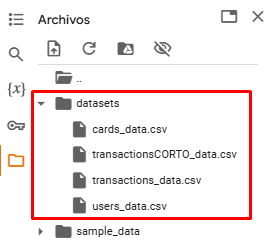

Movemos los ficheros a una carpeta nueva denominada input:

In [7]:
%%bash
hdfs dfs -mkdir input
hdfs dfs -put datasets/cards_data.csv  datasets/transactions_data.csv  datasets/transactionsCORTO_data.csv  datasets/users_data.csv input
hdfs dfs -ls

Found 6 items
drwxr-xr-x   - root root       4096 2026-04-16 13:33 .config
drwxr-xr-x   - root root       4096 2026-04-27 14:29 datasets
drwxr-xr-x   - root root       4096 2026-04-27 14:29 input
drwxr-xr-x   - root root       4096 2017-06-02 13:42 pig-0.17.0
-rw-r--r--   1 root root  230606579 2017-06-16 18:10 pig-0.17.0.tar.gz
drwxr-xr-x   - root root       4096 2026-04-16 13:33 sample_data


Mostramos las primeras líneas de cada fichero:

In [8]:
!hdfs dfs -head input/cards_data.csv

id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No
4537,1746,Visa,Credit,4404898874682993,09/2003,736,YES,1,$27500,09/2003,2012,No
1278,1746,Visa,Debit,4001482973848631,07/2022,972,YES,2,$28508,02/2011,2011,No
3687,1746,Mastercard,Debit,5627220683410948,06/2022,48,YES,2,$9022,07/2003,2015,No
3465,1746,Mastercard,Debit (Prepaid),5711382187309326,11/2020,722,YES,2,$54,06/2010,2015,No
3754,1746,Mastercard,Debit (Prepaid),5766121508358701,02/2023,908,YES,1,$99,07/2006,2012,No
5144,1718,Mastercard,De

In [9]:
!hdfs dfs -head input/transactions_data.csv

id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,
7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,
7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,
7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,
7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,
7475333,2010-01-01 00:07:00,1807,165,$4.81,Swipe Transaction,20519,Bronx,NY,10464.0,5942,
7475334,2010-01-01 00:09:00,1556,2972,$77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,
7475335,2010-01-01 00:14:00,1684,2140,$26.46,Online Transaction,39021,ONLINE,,,4784,
7475336,2010-01-01 00:21:00,335,5131,$261.58,Online Transaction,50292,ONLINE,,,7801,
7475337,2010-01-01 00:21:00,351,1112,$10.74,Swipe Transaction,3864,Flushing,N

In [10]:
!hdfs dfs -head input/users_data.csv

id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5
1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5
708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,$163145,$249925,$202328,722,4
1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,$53797,$109687,$183855,675,1
68,42,70,1977,10,Male,58 Birch Lane,41.55,-90.6,$20599,$41997,$0,704,3
1075,36,67,1983,12,Female,5695 Fifth Street,38.22,-85.74,$25258,$51500,$102286,672,3
1711,26,67,1993,12,Male,1941 Ninth Street,45.51,-122.64,$26790,$54623,$114711,728,1
1116,81,66,1938,7,Female,11 Spruce Avenue,40.32,-75.32,$26273,$42509,$2895,755,5
1752,34,60,1986,1,Female,887 Grant Street,29.97,-92.12,$18730,$38190,$81262,810,1
192,27,66,

---
# **Apartado 2: Visualización y estudio de datos con Pandas**
Usa Pandas para realizar una primera visualización de ellos en forma de tabla, y estudiar los datos: observar si hay valores nulos, fechas con formatos que no se corresponden, campos vacíos...
---
---

In [11]:
import pandas as pd
df_cards = pd.read_csv("input/cards_data.csv")
df_cards.head(5)

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No


Con esta primera comprobación, en el fichero *cards_data.csv* no encontramos valores faltantes o nulos.

Sería interesante modificar el formato de las cantidades que aparecen precedidas del símbolo $ en el campo *credit_limit*, como veremos más adelante.

In [12]:
import pandas as pd
df_transactions = pd.read_csv("input/transactions_data.csv")
df_transactions.head(10)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN
5,7475333,2010-01-01 00:07:00,1807,165,$4.81,Swipe Transaction,20519,Bronx,NY,10464.0,5942,NaN
6,7475334,2010-01-01 00:09:00,1556,2972,$77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
7,7475335,2010-01-01 00:14:00,1684,2140,$26.46,Online Transaction,39021,ONLINE,NaN,NaN,4784,NaN
8,7475336,2010-01-01 00:21:00,335,5131,$261.58,Online Transaction,50292,ONLINE,NaN,NaN,7801,NaN
9,7475337,2010-01-01 00:21:00,351,1112,$10.74,Swipe Transaction,3864,Flushing,NY,11355.0,5813,NaN


Con esta comprobación podemos ver que, además de la cuestión relativa a las cantidades precedidas del símbolo $ que veíamos en el fichero anterior, también encontramos datos faltantes en el campo error.

In [13]:
import pandas as pd
df_users = pd.read_csv("input/users_data.csv")
df_users.head(5)

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,$163145,$249925,$202328,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,$53797,$109687,$183855,675,1


Como podemos ver, en el fichero *users_data.csv* también hay tres campos que incluyen cantidades precedidas del símbolo dólar.

# **Apartado 3: Apache Pig**

### **Limpiar directorios de salida de Pig**

Antes de volver a ejecutar los scripts de Pig, es necesario eliminar los directorios de salida que se crearon en ejecuciones anteriores. Usaremos el comando `hdfs dfs -rm -r` para eliminar estos directorios.

In [14]:
%%bash
hdfs dfs -test -d nulos && hdfs dfs -rm -r nulos
hdfs dfs -test -d limpios && hdfs dfs -rm -r limpios
hdfs dfs -test -d fechas_corregidas && hdfs dfs -rm -r fechas_corregidas
hdfs dfs -test -d city_counts_temp && hdfs dfs -rm -r city_counts_temp
hdfs dfs -test -d city_counts_temp2 && hdfs dfs -rm -r city_counts_temp2

rm: `nulos': No such file or directory
rm: `limpios': No such file or directory
rm: `fechas_corregidas': No such file or directory
rm: `city_counts_temp': No such file or directory
rm: `city_counts_temp2': No such file or directory


CalledProcessError: Command 'b'hdfs dfs -rm -r nulos\nhdfs dfs -rm -r limpios\nhdfs dfs -rm -r fechas_corregidas\nhdfs dfs -rm -r city_counts_temp\nhdfs dfs -rm -r city_counts_temp2\n'' returned non-zero exit status 1.

Una vez ejecutada esta celda, podrás volver a ejecutar tus scripts de Pig sin que te aparezcan los errores de directorios ya existentes.

----
## **Apartado 3.1: Corrección de datos con Pig**
Usa Pig para corregir los fallos en los datos que hayas observado en el punto anterior. (Al menos debes modificar dos campos, por ejemplo cambiar formatos de fechas y rellenar campos vacíos y nulos con valores por defecto).
---
---

#### **Apartado 3.1.1: Procesar Nulos**



En primer lugar, comprobamos si hay nulos en nuestro fichero *transactions_data.csv*:

In [15]:
print(df_transactions.shape)
pd.isnull(df_transactions).any()

(13305915, 12)


,0
id,False
date,False
client_id,False
card_id,False
amount,False
use_chip,False
merchant_id,False
merchant_city,False
merchant_state,True
zip,True


Como podemos ver, no sólo hay nulos en el campo **errors**, sino que también hay en **merchant_state** y en **zip**:

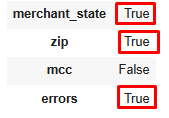

Para construir nuestro código Pig será necesario ver qué columnas tenemos en el fichero:

In [16]:
df_transactions.columns

Index(['id', 'date', 'client_id', 'card_id', 'amount', 'use_chip',
       'merchant_id', 'merchant_city', 'merchant_state', 'zip', 'mcc',
       'errors'],
      dtype='object')

Es más, para facilitarnos la creación de los distintos ficheros .pig que vamos a usar en esta tarea, vamos a extraer el nombre y el tipo de dato de cada columna del dataset que vamos a tratar. Además, vamos a mapear los tipos de datos para establecer la **correspondencia entre los tipos de datos que utiliza Pandas y los que utiliza Apache Pig**.

Finalmente, construimos una cadena con los campos y los tipos de datos que necesitaremos para el fichero .pig:

In [17]:
import pandas as pd

# Recorremos las columnas del dataframe para obtener sus tipos de datos
column_info_string = ""
for column in df_transactions.columns:
    column_info_string += f"{column}:{df_transactions[column].dtype}, "
column_info_string = column_info_string[:-2]  # Eliminar la última coma y el espacio generado

# Imprimimos los tipos de datos de Pandas
print("Tipos de datos de Pandas:")
print(column_info_string)

# Mapeo de tipos de datos de Pandas a tipos de datos de Apache Pig
dtype_mapping = {
    'int64': 'long',
    'float64': 'double',
    'object': 'chararray',
    'bool': 'boolean',
    'datetime64[ns]': 'datetime',
    # Podemos añadir más mapeos si es necesario
}

# Construimos la cadena de tipos de datos de Pig con el formato deseado
pig_dtype_string = ""
for column in df_transactions.columns:
    pandas_dtype = str(df_transactions[column].dtype)
    pig_dtype = dtype_mapping.get(pandas_dtype, 'unknown')  # Obtener el tipo de Pig o 'unknown'
    pig_dtype_string += f"   {column}:{pig_dtype},\n"  # Agregar formato con espacios y salto de línea
pig_dtype_string = pig_dtype_string[:-2]  # Eliminar la última coma y el salto de línea

# Imprimimos los tipos de datos de Apache Pig con el formato deseado
print("\nTipos de datos de Apache Pig:")
print(pig_dtype_string)

Tipos de datos de Pandas:
id:int64, date:object, client_id:int64, card_id:int64, amount:object, use_chip:object, merchant_id:int64, merchant_city:object, merchant_state:object, zip:float64, mcc:int64, errors:object

Tipos de datos de Apache Pig:
   id:long,
   date:chararray,
   client_id:long,
   card_id:long,
   amount:chararray,
   use_chip:chararray,
   merchant_id:long,
   merchant_city:chararray,
   merchant_state:chararray,
   zip:double,
   mcc:long,
   errors:chararray


#####**Apartado 3.1.1.1: Sustituir valores nulos**

A continuación, vamos a mostrar el proceso con Apache Pig para sustituir los valores nulos en los campos concretos.

Escribimos el fichero .pig, indicando los tipos de datos correspondientes que hemos obtenido con el script anterior y las acciones a llevar a cabo cuando se encuentra valores nulos en los campos indicados:

In [18]:
%%writefile procesar_nulos.pig

-- Cargamos los datos del fichero de transacciones y definimos el esquema de datos
transactions = load 'input/transactions_data.csv' using PigStorage(',') as (
   id:long,
   date:chararray,
   client_id:long,
   card_id:long,
   amount:chararray,
   use_chip:chararray,
   merchant_id:long,
   merchant_city:chararray,
   merchant_state:chararray,
   zip:double,
   mcc:long,
   errors:chararray
);

-- Limpiamos los datos, gestionando los valores nulos
transactions_clean = foreach transactions generate
      id..merchant_city,
      ((merchant_state IS NULL) ? 'U' : merchant_state),
      ((zip IS NULL) ? 0 : zip),
      mcc,
      ((errors IS NULL) ? 'N' : errors)
    ;

-- Guardamos los datos limpios
STORE transactions_clean INTO 'nulos' using PigStorage(',');

Writing procesar_nulos.pig


Y lo ejecutamos:

In [19]:
!pig procesar_nulos.pig

2026-04-27 14:54:02,011 INFO pig.ExecTypeProvider: Trying ExecType : LOCAL
2026-04-27 14:54:02,012 INFO pig.ExecTypeProvider: Trying ExecType : MAPREDUCE
2026-04-27 14:54:02,012 INFO pig.ExecTypeProvider: Picked MAPREDUCE as the ExecType
2026-04-27 14:54:02,049 [main] INFO  org.apache.pig.Main - Apache Pig version 0.17.0 (r1797386) compiled Jun 02 2017, 15:41:58
2026-04-27 14:54:02,049 [main] INFO  org.apache.pig.Main - Logging error messages to: /content/pig_1777301642044.log
2026-04-27 14:54:02,266 [main] INFO  org.apache.pig.impl.util.Utils - Default bootup file /root/.pigbootup not found
2026-04-27 14:54:02,305 [main] INFO  org.apache.hadoop.conf.Configuration.deprecation - mapred.job.tracker is deprecated. Instead, use mapreduce.jobtracker.address
2026-04-27 14:54:02,305 [main] INFO  org.apache.pig.backend.hadoop.executionengine.HExecutionEngine - Connecting to hadoop file system at: file:///
2026-04-27 14:54:02,325 [main] INFO  org.apache.pig.PigServer - Pig Script ID for the ses

Finalmente, hacemos una comprobación mediante Python/Pandas, y vemos que ya no hay campos con valores nulos:

In [20]:
df_clean = pd.read_csv("/content/nulos/part-m-00000", skiprows=1, header = None, names = df_transactions.columns)
print(df_clean.shape)
pd.isnull(df_clean).any()


(201755, 12)


,0
id,False
date,False
client_id,False
card_id,False
amount,False
use_chip,False
merchant_id,False
merchant_city,False
merchant_state,False
zip,False


Anteriormente, al usar **head** veíamos que en el campo *errors* aparecía 'NaN'. Si visualizamos las primeras líneas del dataframe que acabamos de crear con Pig, vemos que se ha realizado la sustitución según hemos indicado, puesto que aparece 'N'.

Vamos a mostrar ambos datasets, el original y el procesado:

In [21]:
# Mostrar las primeras líneas del dataframe original
df_transactions.head(10)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN
5,7475333,2010-01-01 00:07:00,1807,165,$4.81,Swipe Transaction,20519,Bronx,NY,10464.0,5942,NaN
6,7475334,2010-01-01 00:09:00,1556,2972,$77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
7,7475335,2010-01-01 00:14:00,1684,2140,$26.46,Online Transaction,39021,ONLINE,NaN,NaN,4784,NaN
8,7475336,2010-01-01 00:21:00,335,5131,$261.58,Online Transaction,50292,ONLINE,NaN,NaN,7801,NaN
9,7475337,2010-01-01 00:21:00,351,1112,$10.74,Swipe Transaction,3864,Flushing,NY,11355.0,5813,NaN


In [22]:
# Mostrar las primeras líneas del dataframe con los valores nulos sustituidos
df_clean.head(10)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,N
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,N
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,N
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,N
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,N
5,7475333,2010-01-01 00:07:00,1807,165,$4.81,Swipe Transaction,20519,Bronx,NY,10464.0,5942,N
6,7475334,2010-01-01 00:09:00,1556,2972,$77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,N
7,7475335,2010-01-01 00:14:00,1684,2140,$26.46,Online Transaction,39021,ONLINE,U,0.0,4784,N
8,7475336,2010-01-01 00:21:00,335,5131,$261.58,Online Transaction,50292,ONLINE,U,0.0,7801,N
9,7475337,2010-01-01 00:21:00,351,1112,$10.74,Swipe Transaction,3864,Flushing,NY,11355.0,5813,N


#####**Apartado 3.1.1.2: Omitir líneas con campos con valores nulos**

Ahora vamos a procesar el mismo fichero *transactions_data.csv*, pero en lugar de sustituir los valores nulos, vamos a omitir las líneas que contienen dichos valores faltantes.

Primero escribimos el fichero .pig:


In [23]:
%%writefile filtrar_nulos.pig

transactions2 = load 'input/transactions_data.csv' using PigStorage(',') as (
   id:long,
   date:chararray,
   client_id:long,
   card_id:long,
   amount:chararray,
   use_chip:chararray,
   merchant_id:long,
   merchant_city:chararray,
   merchant_state:chararray,
   zip:double,
   mcc:long,
   errors:chararray
);

transactions_nulos_omitidos = FILTER transactions2 BY NOT ((merchant_state IS  NULL) OR (zip IS  NULL) OR (errors IS  NULL));

STORE transactions_nulos_omitidos INTO 'limpios' using PigStorage(',');

Writing filtrar_nulos.pig


Ejecutamos el fichero:

In [24]:
!pig filtrar_nulos.pig

2026-04-27 15:09:53,738 INFO pig.ExecTypeProvider: Trying ExecType : LOCAL
2026-04-27 15:09:53,739 INFO pig.ExecTypeProvider: Trying ExecType : MAPREDUCE
2026-04-27 15:09:53,739 INFO pig.ExecTypeProvider: Picked MAPREDUCE as the ExecType
2026-04-27 15:09:53,779 [main] INFO  org.apache.pig.Main - Apache Pig version 0.17.0 (r1797386) compiled Jun 02 2017, 15:41:58
2026-04-27 15:09:53,779 [main] INFO  org.apache.pig.Main - Logging error messages to: /content/pig_1777302593774.log
2026-04-27 15:09:53,998 [main] INFO  org.apache.pig.impl.util.Utils - Default bootup file /root/.pigbootup not found
2026-04-27 15:09:54,035 [main] INFO  org.apache.hadoop.conf.Configuration.deprecation - mapred.job.tracker is deprecated. Instead, use mapreduce.jobtracker.address
2026-04-27 15:09:54,035 [main] INFO  org.apache.pig.backend.hadoop.executionengine.HExecutionEngine - Connecting to hadoop file system at: file:///
2026-04-27 15:09:54,054 [main] INFO  org.apache.pig.PigServer - Pig Script ID for the ses

Finalmente, hacemos una comprobación mediante Python/Pandas:

In [25]:
import csv #Usamos esta biblioteca porque si no da un error relacionado con comillas dobles en el contenido del dataset
df_transactions_nulos_omitidos = pd.read_csv("/content/limpios/part-m-00000", skiprows=1, header = None, names = df_transactions.columns, quoting=csv.QUOTE_NONE)
print(df_transactions_nulos_omitidos.shape)
pd.isnull(df_transactions_nulos_omitidos).any()


(4576, 12)


,0
id,False
date,False
client_id,False
card_id,False
amount,False
use_chip,False
merchant_id,False
merchant_city,False
merchant_state,False
zip,False


Ya no aparece ningún campo con valores nulos.

Anteriormente, al usar head veíamos que en el campo errors aparecía 'NaN'. Si visualizamos las primeras líneas del dataset que acabamos de procesar con Pig, vemos que ahora se han omitido las líneas que contenían valores nulos.

De nuevo, vamos a mostrar tanto el dataset original como el procesado:

In [26]:
#Aquí vemos las primeras líneas del dataframe original
df_transactions.head(10)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,4829,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,5813,NaN
5,7475333,2010-01-01 00:07:00,1807,165,$4.81,Swipe Transaction,20519,Bronx,NY,10464.0,5942,NaN
6,7475334,2010-01-01 00:09:00,1556,2972,$77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
7,7475335,2010-01-01 00:14:00,1684,2140,$26.46,Online Transaction,39021,ONLINE,NaN,NaN,4784,NaN
8,7475336,2010-01-01 00:21:00,335,5131,$261.58,Online Transaction,50292,ONLINE,NaN,NaN,7801,NaN
9,7475337,2010-01-01 00:21:00,351,1112,$10.74,Swipe Transaction,3864,Flushing,NY,11355.0,5813,NaN


In [27]:
#Aquí vemos las primeras líneas del dataframe sin valores nulos. Podemos comprobar que se han omitido las líneas que contienen campos erróneos o nulos.
df_transactions_nulos_omitidos.head(10)

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475792,2010-01-01 07:02:00,1424,4710,$-72.00,Swipe Transaction,59935,Kingman,AZ,86401.0,5499,Insufficient Balance
1,7475881,2010-01-01 07:22:00,843,184,$37.54,Swipe Transaction,89462,Terre Haute,IN,47805.0,5300,Insufficient Balance
2,7475882,2010-01-01 07:22:00,1424,4710,$72.00,Swipe Transaction,59935,Kingman,AZ,86401.0,5499,Insufficient Balance
3,7475935,2010-01-01 07:37:00,319,248,$104.81,Swipe Transaction,9263,Fresno,CA,93727.0,5912,Insufficient Balance
4,7476174,2010-01-01 08:36:00,1782,4289,$2.46,Swipe Transaction,40948,Westminster,CA,92683.0,5411,Insufficient Balance
5,7476516,2010-01-01 09:58:00,373,2817,$1.31,Swipe Transaction,69831,Grabill,IN,46741.0,5812,Bad PIN
6,7476593,2010-01-01 10:12:00,1153,2021,$78.48,Swipe Transaction,22204,Aurora,CO,80013.0,5541,Insufficient Balance
7,7476617,2010-01-01 10:17:00,1153,2021,$78.48,Swipe Transaction,22204,Aurora,CO,80013.0,5541,Insufficient Balance
8,7476677,2010-01-01 10:32:00,408,2515,$16.07,Swipe Transaction,96049,Birchwood,WI,54817.0,5541,Technical Glitch
9,7476898,2010-01-01 11:17:00,1129,5492,$23.42,Swipe Transaction,61738,Fresno,CA,93722.0,5094,Bad PIN


### **Apartado 3.1.2: Procesar Fecha**

En primer lugar, vamos a observar qué formato de fecha tiene el fichero con el que vamos a trabajar en este apartado, que es *cards_data.csv*:

In [28]:
import pandas as pd

df_cards = pd.read_csv("input/cards_data.csv")

df_cards.head(5)

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No


Como vemos, los campos *expires* y *acct_open_date* aparecen con formato MM/YYYY.

Vamos a crear un script que verifique si hay fechas en esas columnas que tengan un formato diferente:

In [29]:
import pandas as pd

def buscar_fechas_incorrectas(df, columna):
    try:
        pd.to_datetime(df[columna], format='%m/%Y') #Indicamos el formato que debe tener la fecha para considerarse correcto: el número de mes con dos dígitos y el año con cuatro dígitos
        return False
    except (ValueError, TypeError):
        return True

# Buscar fechas incorrectas en 'expires'
df_cards['expires_incorrecta'] = df_cards.apply(buscar_fechas_incorrectas, axis=1, columna='expires')

# Buscar fechas incorrectas en 'acct_open_date'
df_cards['acct_open_date_incorrecta'] = df_cards.apply(buscar_fechas_incorrectas, axis=1, columna='acct_open_date')

# Filtrar el DataFrame para mostrar filas con al menos una fecha incorrecta
fechas_incorrectas = df_cards[(df_cards['expires_incorrecta']) | (df_cards['acct_open_date_incorrecta'])]

# Mostramos el dataframe generado
fechas_incorrectas

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,expires_incorrecta,acct_open_date_incorrecta


Parece que todas las fechas tienen el formato MM/YYYY, así que vamos a forzar un cambio de formato en determinadas filas para poder hacer un ejemplo de procesado de fechas.

En primer lugar, vamos a utilizar **grep** para localizar si hay líneas con, por ejemplo, la fecha "08/2024". Para ello, vamos a crear un nuevo fichero para trabajar sobre él, denominado *cards_fechas_incorrectas.csv*:

In [30]:
# Convierte el DataFrame a un archivo CSV
df_cards.to_csv('input/cards_fechas_incorrectas.csv', index=False)

# Usa grep para buscar la fecha "08/2024" en el archivo CSV
!grep "08/2024" input/cards_fechas_incorrectas.csv

42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No,False,False
3679,1946,Visa,Debit,4869845530765333,08/2024,701,YES,2,$4488,07/2002,2015,No,False,False
1395,643,Amex,Credit,381572912003735,08/2024,145,YES,1,$10000,02/2020,2020,No,False,False
1470,1161,Mastercard,Credit,5597117503471640,08/2024,934,NO,1,$16100,02/2020,2020,No,False,False
3310,996,Mastercard,Debit,5691123059106648,08/2024,190,YES,2,$18861,06/2006,2011,No,False,False
460,1159,Mastercard,Debit,5786593463189278,08/2024,58,YES,1,$16330,01/2020,2020,No,False,False
4548,1128,Mastercard,Debit,5493545357380440,08/2024,774,YES,2,$15110,09/2004,2009,No,False,False
4098,1341,Mastercard,Debit,5676742282559057,08/2024,195,YES,1,$24926,08/2001,2011,No,False,False
4473,1543,Visa,Debit,4559874462694124,08/2024,810,YES,2,$39389,08/2018,2018,No,False,False
3729,901,Discover,Credit,6630783814792741,08/2024,24,YES,1,$9600,07/2005,2012,No,False,False
44,1267,Visa,Debit,4194403279790054,08/2024,282,YES,2,$27584,01/20

Como vemos que hay bastantes filas con esa fecha concreta, vamos a sustituirlas en el nuevo fichero que hemos creado, usando la herramienta **sed**:

In [31]:
# Usa sed para sustituir "08/2024" por "2024-08" en el archivo CSV
!sed -i 's/08\/2024/2024-08/g' input/cards_fechas_incorrectas.csv

# Vuelve a leer el archivo CSV modificado en un DataFrame
df_cards_fechas_incorrectas = pd.read_csv('input/cards_fechas_incorrectas.csv')

Ahora buscamos la cadena "incorrecta" (2024-08) manualmente:

In [32]:
# Usa grep para buscar la fecha "08/2024" en el archivo CSV
!grep "08/2024" input/cards_fechas_incorrectas.csv

No muestra resultados.

In [33]:
# Usa grep para buscar la fecha "2024-08" en el archivo CSV
!grep "2024-08" input/cards_fechas_incorrectas.csv

42,825,Visa,Credit,4879494103069057,2024-08,693,NO,1,$12400,01/2003,2012,No,False,False
3679,1946,Visa,Debit,4869845530765333,2024-08,701,YES,2,$4488,07/2002,2015,No,False,False
1395,643,Amex,Credit,381572912003735,2024-08,145,YES,1,$10000,02/2020,2020,No,False,False
1470,1161,Mastercard,Credit,5597117503471640,2024-08,934,NO,1,$16100,02/2020,2020,No,False,False
3310,996,Mastercard,Debit,5691123059106648,2024-08,190,YES,2,$18861,06/2006,2011,No,False,False
460,1159,Mastercard,Debit,5786593463189278,2024-08,58,YES,1,$16330,01/2020,2020,No,False,False
4548,1128,Mastercard,Debit,5493545357380440,2024-08,774,YES,2,$15110,09/2004,2009,No,False,False
4098,1341,Mastercard,Debit,5676742282559057,2024-08,195,YES,1,$24926,08/2001,2011,No,False,False
4473,1543,Visa,Debit,4559874462694124,2024-08,810,YES,2,$39389,08/2018,2018,No,False,False
3729,901,Discover,Credit,6630783814792741,2024-08,24,YES,1,$9600,07/2005,2012,No,False,False
44,1267,Visa,Debit,4194403279790054,2024-08,282,YES,2,$27584,01/20

Vemos que se han sustituido.

Y mostramos con **head** la diferencia entre un formato y otro:

In [34]:
df_cards_fechas_incorrectas.head(10)

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,expires_incorrecta,acct_open_date_incorrecta
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No,False,False
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No,False,False
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No,False,False
3,42,825,Visa,Credit,4879494103069057,2024-08,693,NO,1,$12400,01/2003,2012,No,False,False
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No,False,False
5,4537,1746,Visa,Credit,4404898874682993,09/2003,736,YES,1,$27500,09/2003,2012,No,False,False
6,1278,1746,Visa,Debit,4001482973848631,07/2022,972,YES,2,$28508,02/2011,2011,No,False,False
7,3687,1746,Mastercard,Debit,5627220683410948,06/2022,48,YES,2,$9022,07/2003,2015,No,False,False
8,3465,1746,Mastercard,Debit (Prepaid),5711382187309326,11/2020,722,YES,2,$54,06/2010,2015,No,False,False
9,3754,1746,Mastercard,Debit (Prepaid),5766121508358701,02/2023,908,YES,1,$99,07/2006,2012,No,False,False


Vemos que se ha sustituido correctamente:

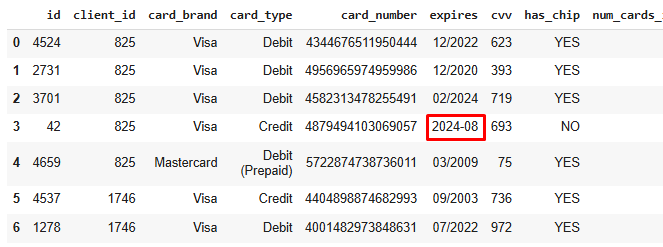

A continuación, volvemos a usar el script que nos muestra las líneas con formato de fecha incorrecta. Veremos que ahora sí muestra resultados:

In [35]:
import pandas as pd

def buscar_fechas_incorrectas(df, columna):
    try:
        pd.to_datetime(df[columna], format='%m/%Y')
        return False
    except (ValueError, TypeError):
        return True

# Buscar fechas incorrectas en 'expires'
df_cards_fechas_incorrectas['expires_incorrecta'] = df_cards_fechas_incorrectas.apply(buscar_fechas_incorrectas, axis=1, columna='expires')

# Buscar fechas incorrectas en 'acct_open_date'
df_cards_fechas_incorrectas['acct_open_date_incorrecta'] = df_cards_fechas_incorrectas.apply(buscar_fechas_incorrectas, axis=1, columna='acct_open_date')

# Filtrar el DataFrame para mostrar filas con al menos una fecha incorrecta
fechas_incorrectas = df_cards_fechas_incorrectas[(df_cards_fechas_incorrectas['expires_incorrecta']) | (df_cards_fechas_incorrectas['acct_open_date_incorrecta'])]

# Mostramos el dataset
fechas_incorrectas

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,expires_incorrecta,acct_open_date_incorrecta
3,42,825,Visa,Credit,4879494103069057,2024-08,693,NO,1,$12400,01/2003,2012,No,True,False
70,3679,1946,Visa,Debit,4869845530765333,2024-08,701,YES,2,$4488,07/2002,2015,No,True,False
185,1395,643,Amex,Credit,381572912003735,2024-08,145,YES,1,$10000,02/2020,2020,No,True,False
205,1470,1161,Mastercard,Credit,5597117503471640,2024-08,934,NO,1,$16100,02/2020,2020,No,True,False
281,3310,996,Mastercard,Debit,5691123059106648,2024-08,190,YES,2,$18861,06/2006,2011,No,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5760,6073,2,Mastercard,Debit,5617443939610345,2024-08,813,YES,2,$16491,12/2012,2012,No,True,False
5785,3507,1091,Visa,Credit,4724864981660920,2024-08,403,NO,1,$12700,06/2010,2013,No,True,False
5814,3875,699,Visa,Debit,4029109059179282,2024-08,637,YES,2,$8960,07/2008,2014,No,True,False
5849,1991,459,Visa,Debit,4702909631016695,2024-08,296,YES,1,$13496,02/2020,2020,No,True,False


Nuevamente, nos ayudamos del script de mapeo de datos para construir más adelante nuestro fichero .pig para cambiar el formato de fechas:

In [36]:
import pandas as pd

# Recorremos las columnas del dataframe y creamos la cadena
column_info_string = ""
for column in df_cards_fechas_incorrectas.columns:
  column_info_string += f"{column}:{df_cards_fechas_incorrectas[column].dtype}, "
column_info_string = column_info_string[:-2] # Eliminar la última coma y el último espacio generado

# Imprimir los resultados
column_info_string

# Imprimimos los tipos de datos de Pandas
print("Tipos de datos de Pandas:")
print(column_info_string)

# Mapeo de tipos de datos de Pandas a tipos de datos de Apache Pig
dtype_mapping = {
    'int64': 'long',
    'float64': 'double',
    'object': 'chararray',
    'bool': 'boolean',
    'datetime64[ns]': 'datetime',
    # Podemos añadir más mapeos si es necesario
}

# Construimos la cadena de tipos de datos de Pig con el formato deseado
pig_dtype_string = ""
for column in df_cards_fechas_incorrectas.columns:
    pandas_dtype = str(df_cards_fechas_incorrectas[column].dtype)
    pig_dtype = dtype_mapping.get(pandas_dtype, 'unknown')  # Obtener el tipo de Pig o 'unknown'
    pig_dtype_string += f"   {column}:{pig_dtype},\n"  # Agregar formato con espacios y salto de línea
pig_dtype_string = pig_dtype_string[:-2]  # Eliminar la última coma y el salto de línea

# Imprimimos los tipos de datos de Apache Pig con el formato deseado
print("\nTipos de datos de Apache Pig:")
print(pig_dtype_string)

Tipos de datos de Pandas:
id:int64, client_id:int64, card_brand:object, card_type:object, card_number:int64, expires:object, cvv:int64, has_chip:object, num_cards_issued:int64, credit_limit:object, acct_open_date:object, year_pin_last_changed:int64, card_on_dark_web:object, expires_incorrecta:bool, acct_open_date_incorrecta:bool

Tipos de datos de Apache Pig:
   id:long,
   client_id:long,
   card_brand:chararray,
   card_type:chararray,
   card_number:long,
   expires:chararray,
   cvv:long,
   has_chip:chararray,
   num_cards_issued:long,
   credit_limit:chararray,
   acct_open_date:chararray,
   year_pin_last_changed:long,
   card_on_dark_web:chararray,
   expires_incorrecta:boolean,
   acct_open_date_incorrecta:boolean


Una vez obtenidos los tipos de datos equivalentes, escribimos el fichero pig, indicando que se reemplacen los valores originales por el formato de fechas MM/YYYY:

In [37]:
%%writefile procesar_fechas.pig

-- Cargar los datos
a = load 'input/cards_fechas_incorrectas.csv' using PigStorage(',') as (
    id:long,
    client_id:long,
    card_brand:chararray,
    card_type:chararray,
    card_number:long,
    expires:chararray,
    cvv:long,
    has_chip:chararray,
    num_cards_issued:long,
    credit_limit:chararray,
    acct_open_date:chararray,
    year_pin_last_changed:long,
    card_on_dark_web:chararray,
    expires_incorrecta:boolean,
    acct_open_date_incorrecta:boolean
);

-- Corregir fechas en ambas columnas reemplazando directamente los valores originales
fechas_corregidas = foreach a generate
    id,
    client_id,
    card_brand,
    card_type,
    card_number,
    (expires matches '\\d{4}-\\d{2}' ? REPLACE(expires, '(\\d{4})-(\\d{2})', '$2/$1') : expires) as expires, -- Reemplaza directamente 'expires'
    cvv,
    has_chip,
    num_cards_issued,
    credit_limit,
    (acct_open_date matches '\\d{4}-\\d{2}' ? REPLACE(acct_open_date, '(\\d{4})-(\\d{2})', '$2/$1') : acct_open_date) as acct_open_date, -- Reemplaza directamente 'acct_open_date'
    year_pin_last_changed,
    card_on_dark_web,
    expires_incorrecta,
    acct_open_date_incorrecta;

-- Guardar los datos corregidos
STORE fechas_corregidas INTO 'fechas_corregidas' USING PigStorage(',');


Writing procesar_fechas.pig


Ejecutamos el fichero que acabamos de crear

In [38]:
!pig procesar_fechas.pig

2026-04-27 15:10:44,959 INFO pig.ExecTypeProvider: Trying ExecType : LOCAL
2026-04-27 15:10:44,960 INFO pig.ExecTypeProvider: Trying ExecType : MAPREDUCE
2026-04-27 15:10:44,960 INFO pig.ExecTypeProvider: Picked MAPREDUCE as the ExecType
2026-04-27 15:10:45,008 [main] INFO  org.apache.pig.Main - Apache Pig version 0.17.0 (r1797386) compiled Jun 02 2017, 15:41:58
2026-04-27 15:10:45,009 [main] INFO  org.apache.pig.Main - Logging error messages to: /content/pig_1777302645001.log
2026-04-27 15:10:45,239 [main] INFO  org.apache.pig.impl.util.Utils - Default bootup file /root/.pigbootup not found
2026-04-27 15:10:45,280 [main] INFO  org.apache.hadoop.conf.Configuration.deprecation - mapred.job.tracker is deprecated. Instead, use mapreduce.jobtracker.address
2026-04-27 15:10:45,280 [main] INFO  org.apache.pig.backend.hadoop.executionengine.HExecutionEngine - Connecting to hadoop file system at: file:///
2026-04-27 15:10:45,306 [main] INFO  org.apache.pig.PigServer - Pig Script ID for the ses

Para comprobar el resultado del procesamiento realizado, podemos repetir la búsqueda que habíamos hecho anteriormente en la carpeta de resultados:

In [39]:
!grep "2024-08" /content/fechas_corregidas/*

Vemos que la búsqueda de la cadena "2024-08" ahora no arroja resultados.

Comprobemos si la búsqueda de "08/2024" muestra líneas:

In [40]:
!grep "08/2024" /content/fechas_corregidas/*

/content/fechas_corregidas/part-m-00000:42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No,false,false
/content/fechas_corregidas/part-m-00000:3679,1946,Visa,Debit,4869845530765333,08/2024,701,YES,2,$4488,07/2002,2015,No,false,false
/content/fechas_corregidas/part-m-00000:1395,643,Amex,Credit,381572912003735,08/2024,145,YES,1,$10000,02/2020,2020,No,false,false
/content/fechas_corregidas/part-m-00000:1470,1161,Mastercard,Credit,5597117503471640,08/2024,934,NO,1,$16100,02/2020,2020,No,false,false
/content/fechas_corregidas/part-m-00000:3310,996,Mastercard,Debit,5691123059106648,08/2024,190,YES,2,$18861,06/2006,2011,No,false,false
/content/fechas_corregidas/part-m-00000:460,1159,Mastercard,Debit,5786593463189278,08/2024,58,YES,1,$16330,01/2020,2020,No,false,false
/content/fechas_corregidas/part-m-00000:4548,1128,Mastercard,Debit,5493545357380440,08/2024,774,YES,2,$15110,09/2004,2009,No,false,false
/content/fechas_corregidas/part-m-00000:4098,1341,Mastercard,Debit,

Como podemos ver, se han reemplazado correctamente el formato de fechas YYYY-MM por MM/YYYY.

Podríamos meter el resultado en un dataframe para explorarlo y trabajar con él:

In [41]:
import pandas as pd
import glob  # Para buscar archivos con patrones

# Buscar todos los archivos part-m-* en el directorio
file_pattern = 'fechas_corregidas/part-m-*'
files = glob.glob(file_pattern)

# Leer y combinar todos los archivos
df_fechas_procesadas = pd.concat((pd.read_csv(file) for file in files), ignore_index=True)

# Asignar nombres a las columnas
df_fechas_procesadas.columns = [
    'id', 'client_id', 'card_brand', 'card_type', 'card_number',
    'expires', 'cvv', 'has_chip', 'num_cards_issued', 'credit_limit',
    'acct_open_date', 'year_pin_last_changed', 'card_on_dark_web',
    'expires_incorrecta', 'acct_open_date_incorrecta'
]

# Ver las primeras filas
print(df_fechas_procesadas.head())


     id  client_id  card_brand        card_type       card_number  expires  \
0  4524        825        Visa            Debit  4344676511950444  12/2022   
1  2731        825        Visa            Debit  4956965974959986  12/2020   
2  3701        825        Visa            Debit  4582313478255491  02/2024   
3    42        825        Visa           Credit  4879494103069057  08/2024   
4  4659        825  Mastercard  Debit (Prepaid)  5722874738736011  03/2009   

   cvv has_chip  num_cards_issued credit_limit acct_open_date  \
0  623      YES                 2       $24295        09/2002   
1  393      YES                 2       $21968        04/2014   
2  719      YES                 2       $46414        07/2003   
3  693       NO                 1       $12400        01/2003   
4   75      YES                 1          $28        09/2008   

   year_pin_last_changed card_on_dark_web  expires_incorrecta  \
0                   2008               No               False   
1         

### **Apartado 3.1.3: Procesar cantidades monetarias**

Como comentábamos anteriormente, todas las cantidades aparecen precedidas del símbolo dolar en los tres ficheros CSV.

Vamos a utilizar Apache Pig para normalizar el formato de esos campos.

Escribimos el fichero .pig:

In [42]:
%%writefile limpiar_dolar.pig
-- Cargar los datos desde el archivo CSV
cards_data = LOAD 'input/cards_data.csv' USING PigStorage(',')
    AS (id:int, client_id:int, card_brand:chararray, card_type:chararray,
        card_number:chararray, expires:chararray, cvv:int, has_chip:chararray,
        num_cards_issued:int, credit_limit:chararray, acct_open_date:chararray,
        year_pin_last_changed:int, card_on_dark_web:chararray);

-- Limpiar la columna credit_limit eliminando caracteres no numéricos
cards_data_limpio = FOREACH cards_data GENERATE
    id, client_id, card_brand, card_type, card_number, expires, cvv,
    has_chip, num_cards_issued,
    (double) REGEX_EXTRACT(credit_limit, '([0-9.]+)', 1) AS credit_limit,
    acct_open_date, year_pin_last_changed, card_on_dark_web;

-- Mostrar los datos después de limpiar (para verificación)
DUMP cards_data_limpio;


Writing limpiar_dolar.pig


Usamos una expresión regular ([0-9.]+) para extraer sólo los números y puntos decimales de la columna *credit_limit*.
Si esa columna contiene valores como "$1,500.50" o "USD 2000", este proceso extraerá solo 1500.50 o 2000.

Además, conviertimos el valor extraído en un número decimal (double), asegurando que no se trate como una cadena de texto (chararray).

Finalmente, renombramos el campo limpio para que mantenga el mismo nombre en la nueva tabla.

Ejecutamos el fichero que acabamos de escribir:

In [43]:
!pig limpiar_dolar.pig

Se han truncado las últimas 5000 líneas del flujo de salida.
(1530,785,Mastercard,Debit (Prepaid),5802808293999580,02/2023,374,NO,1,80.0,02/2020,2020,No)
(507,785,Mastercard,Credit,5182039113510183,12/2024,533,YES,1,15400.0,01/2020,2020,No)
(2638,662,Mastercard,Debit,5178588521108553,04/2021,647,YES,2,28747.0,04/2010,2010,No)
(3092,662,Mastercard,Debit (Prepaid),5419683819223054,07/2021,690,YES,2,110.0,05/2011,2011,No)
(5107,847,Mastercard,Debit (Prepaid),5207548471157063,04/2022,310,YES,2,112.0,10/2008,2012,No)
(3416,847,Discover,Credit,6133343341617022,12/2010,252,NO,2,9700.0,06/2009,2011,No)
(5581,847,Visa,Credit,4013077897978419,10/2013,359,YES,1,8600.0,11/2009,2014,No)
(987,847,Mastercard,Debit (Prepaid),5582481832840083,10/2004,949,YES,2,43.0,02/2001,2012,No)
(5998,847,Mastercard,Debit,5160679758487908,04/2015,716,YES,2,19629.0,12/2010,2011,No)
(4531,847,Mastercard,Credit,5350725222706426,04/2021,29,YES,2,3400.0,09/2003,2008,No)
(1531,685,Mastercard,Debit,5208287929207582,01/2022

Como vemos, se ha ejecutado con éxito.

## **Apartado 3.2 — Tratamiento de datos con Pig**
Vamos a realizar un tratamiento de datos con Pig para obtener las 10 ciudades donde se han realizado más transacciones.

Para ello, vamos a trabajar sobre el fichero *transactions_data.csv*. De nuevo, vamos a utilizar el siguiente script para obtener los campos y poderlos utilizar posteriormente en el archivo pig que tenemos que crear:

In [44]:
import pandas as pd

# Recorremos las columnas del dataframe para obtener sus tipos de datos
column_info_string = ""
for column in df_transactions.columns:
    column_info_string += f"{column}:{df_transactions[column].dtype}, "
column_info_string = column_info_string[:-2]  # Eliminar la última coma y el espacio generado

# Imprimimos los tipos de datos de Pandas
print("Tipos de datos de Pandas:")
print(column_info_string)

# Mapeo de tipos de datos de Pandas a tipos de datos de Apache Pig
dtype_mapping = {
    'int64': 'long',
    'float64': 'double',
    'object': 'chararray',
    'bool': 'boolean',
    'datetime64[ns]': 'datetime',
    # Podemos añadir más mapeos si es necesario
}

# Construimos la cadena de tipos de datos de Pig con el formato deseado
pig_dtype_string = ""
for column in df_transactions.columns:
    pandas_dtype = str(df_transactions[column].dtype)
    pig_dtype = dtype_mapping.get(pandas_dtype, 'unknown')  # Obtener el tipo de Pig o 'unknown'
    pig_dtype_string += f"   {column}:{pig_dtype},\n"  # Agregar formato con espacios y salto de línea
pig_dtype_string = pig_dtype_string[:-2]  # Eliminar la última coma y el salto de línea

# Imprimimos los tipos de datos de Apache Pig con el formato deseado
print("\nTipos de datos de Apache Pig:")
print(pig_dtype_string)

Tipos de datos de Pandas:
id:int64, date:object, client_id:int64, card_id:int64, amount:object, use_chip:object, merchant_id:int64, merchant_city:object, merchant_state:object, zip:float64, mcc:int64, errors:object

Tipos de datos de Apache Pig:
   id:long,
   date:chararray,
   client_id:long,
   card_id:long,
   amount:chararray,
   use_chip:chararray,
   merchant_id:long,
   merchant_city:chararray,
   merchant_state:chararray,
   zip:double,
   mcc:long,
   errors:chararray


Una vez que tenemos los campos, los tipos de datos y la equivalencia con Apache Pig, ya podemos crear el fichero pig:

In [45]:
%%writefile citycounts_transactions_top10.pig

transactions = LOAD '/content/input/transactions_data.csv' using PigStorage(',') as (
    id:long, date:chararray, client_id:long, card_id:long, amount:chararray,
    use_chip:chararray, merchant_id:long, merchant_city:chararray,
    merchant_state:chararray, zip:double, mcc:long, errors:chararray);

-- Agrupación por ciudad (GROUP BY)
city_group = GROUP transactions by merchant_city;

-- Contar las apariciones de cada ciudad
city_counts = FOREACH city_group GENERATE group, COUNT(transactions) as cnt;

-- Ordenar por número de apariciones en orden descendente
city_counts_ordered = ORDER city_counts BY cnt DESC;

-- Guardar en un archivo temporal (necesario para evitar errores con el LIMIT y MapReduce)
STORE city_counts_ordered INTO 'city_counts_temp';

-- Cargar desde el archivo temporal (necesario para evitar errores con el LIMIT y MapReduce)
city_counts_temp = LOAD 'city_counts_temp' using PigStorage() as (city:chararray, cnt:long);

-- Limitar a las 10 primeras ciudades
top10_cities = LIMIT city_counts_temp 10;

-- Mostrar los resultados
DUMP top10_cities;

Writing citycounts_transactions_top10.pig


Y lo ejecutamos:

In [46]:
!pig citycounts_transactions_top10.pig

2026-04-27 15:11:02,223 INFO pig.ExecTypeProvider: Trying ExecType : LOCAL
2026-04-27 15:11:02,224 INFO pig.ExecTypeProvider: Trying ExecType : MAPREDUCE
2026-04-27 15:11:02,224 INFO pig.ExecTypeProvider: Picked MAPREDUCE as the ExecType
2026-04-27 15:11:02,270 [main] INFO  org.apache.pig.Main - Apache Pig version 0.17.0 (r1797386) compiled Jun 02 2017, 15:41:58
2026-04-27 15:11:02,270 [main] INFO  org.apache.pig.Main - Logging error messages to: /content/pig_1777302662262.log
2026-04-27 15:11:02,476 [main] INFO  org.apache.pig.impl.util.Utils - Default bootup file /root/.pigbootup not found
2026-04-27 15:11:02,519 [main] INFO  org.apache.hadoop.conf.Configuration.deprecation - mapred.job.tracker is deprecated. Instead, use mapreduce.jobtracker.address
2026-04-27 15:11:02,520 [main] INFO  org.apache.pig.backend.hadoop.executionengine.HExecutionEngine - Connecting to hadoop file system at: file:///
2026-04-27 15:11:02,541 [main] INFO  org.apache.pig.PigServer - Pig Script ID for the ses

Como podemos ver, entre las 10 ciudades con más transacciones se incluye en primer lugar las transacciones realizadas en tiendas online:

1. ONLINE,1563700
2. Houston,146917
3. Miami,87388
4. Brooklyn,84020
5. Los Angeles,82004
6. Chicago,72540
7. Dallas,71864
8. Louisville,66088
9. Philadelphia,61419
10. San Antonio,59265

Si estuviéramos en un entorno real de producción y nos pidieran, por ejemplo, que nos ciñéramos a **ciudades** propiamente dichas, podríamos proceder de la siguiente forma:

In [47]:
%%writefile citycounts_transactions_top10_filtered-sinONLINE.pig

transactions = LOAD '/content/input/transactions_data.csv' using PigStorage(',') as (
    id:long, date:chararray, client_id:long, card_id:long, amount:chararray,
    use_chip:chararray, merchant_id:long, merchant_city:chararray,
    merchant_state:chararray, zip:double, mcc:long, errors:chararray);

-- Filtrar para omitir la palabra "ONLINE"
filtered_transactions = FILTER transactions BY merchant_city != 'ONLINE';

-- Agrupación por ciudad (GROUP BY)
city_group = GROUP filtered_transactions by merchant_city;

-- Contar las apariciones de cada ciudad
city_counts = FOREACH city_group GENERATE group, COUNT(filtered_transactions) as cnt;

-- Ordenar por número de apariciones en orden descendente
city_counts_ordered = ORDER city_counts BY cnt DESC;

-- Guardar en un archivo temporal
STORE city_counts_ordered INTO 'city_counts_temp2';

-- Cargar desde el archivo temporal
city_counts_temp2 = LOAD 'city_counts_temp2' using PigStorage() as (city:chararray, cnt:long);

-- Limitar a las 10 primeras ciudades
top10_cities = LIMIT city_counts_temp2 10;

-- Mostrar los resultados
DUMP top10_cities;

Writing citycounts_transactions_top10_filtered-sinONLINE.pig


Ejecutamos el fichero:

In [48]:
!pig citycounts_transactions_top10_filtered-sinONLINE.pig

2026-04-27 15:12:31,787 INFO pig.ExecTypeProvider: Trying ExecType : LOCAL
2026-04-27 15:12:31,788 INFO pig.ExecTypeProvider: Trying ExecType : MAPREDUCE
2026-04-27 15:12:31,788 INFO pig.ExecTypeProvider: Picked MAPREDUCE as the ExecType
2026-04-27 15:12:31,834 [main] INFO  org.apache.pig.Main - Apache Pig version 0.17.0 (r1797386) compiled Jun 02 2017, 15:41:58
2026-04-27 15:12:31,834 [main] INFO  org.apache.pig.Main - Logging error messages to: /content/pig_1777302751826.log
2026-04-27 15:12:32,069 [main] INFO  org.apache.pig.impl.util.Utils - Default bootup file /root/.pigbootup not found
2026-04-27 15:12:32,111 [main] INFO  org.apache.hadoop.conf.Configuration.deprecation - mapred.job.tracker is deprecated. Instead, use mapreduce.jobtracker.address
2026-04-27 15:12:32,111 [main] INFO  org.apache.pig.backend.hadoop.executionengine.HExecutionEngine - Connecting to hadoop file system at: file:///
2026-04-27 15:12:32,132 [main] INFO  org.apache.pig.PigServer - Pig Script ID for the ses

De este modo, vemos que en la lista ha entrado en último lugar la ciudad de Indianapolis, con 58258 apariciones, y se ha omitido la palabra ONLINE.

---
# **Apartado 4: Spark (PySpark)**
Usa Spark (PySpark) para importar tus ficheros a una base de datos relacional Hive.
---
---

En primer lugar, instalamos Apache Spark y configuramos las variables de entorno:

In [49]:
# Usamos el archivo de Apache para asegurar la disponibilidad de la versión
!wget -q https://archive.apache.org/dist/spark/spark-3.5.4/spark-3.5.4-bin-hadoop3.tgz
!tar xf spark-3.5.4-bin-hadoop3.tgz
!pip install -q findspark
import os
# Actualizamos a Java 17
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.4-bin-hadoop3"
import findspark
findspark.init()

^C
^C


KeyboardInterrupt: 

In [ ]:
ls -l $SPARK_HOME

A continuación, creamos una sesión de Spark para que se ejecute en modo local utilizando todos los núcleos disponibles, indicando como nombre de aplicación *BDA03-IsraelJaime*. También obtenemos el contexto de Spark.

In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .master("local[*]") \
    .appName("BDA03-IsraelJaime") \
    .getOrCreate()

sc = spark.sparkContext

Leemos los ficheros CSV en un dataframes y los guardamos:

In [ ]:
cards_data = spark.read.csv('input/cards_data.csv',sep = ",", inferSchema=True, header=True)
transactions_data = spark.read.csv('input/transactions_data.csv',sep = ",", inferSchema=True, header=True)
users_data = spark.read.csv('input/users_data.csv',sep = ",", inferSchema=True, header=True)

Creamos la base de datos:

In [ ]:
spark.sql("CREATE DATABASE IF NOT EXISTS bd_IsraelJaime")

Usamos los dataframes que acabamos de crear para guardarlos como tablas:

In [ ]:
cards_data.write.mode("overwrite").saveAsTable("bd_IsraelJaime.cards_data")
transactions_data.write.mode("overwrite").saveAsTable("bd_IsraelJaime.transactions_data")
users_data.write.mode("overwrite").saveAsTable("bd_IsraelJaime.users_data")

A través de la ejecución de las siguientes celdas mostramos distinta información de las tablas creadas:

In [ ]:
spark.sql("SHOW TABLES IN bd_IsraelJaime").show()

In [ ]:
spark.catalog.listTables("bd_IsraelJaime")

In [ ]:
spark.sql("DESCRIBE TABLE EXTENDED bd_IsraelJaime.cards_data").show()

In [ ]:
spark.sql("DESCRIBE TABLE EXTENDED bd_IsraelJaime.transactions_data").show()

In [ ]:
spark.sql("DESCRIBE TABLE EXTENDED bd_IsraelJaime.users_data").show()

In [ ]:
spark.sql("SELECT * FROM bd_IsraelJaime.cards_data LIMIT 10").show()
spark.sql("SELECT * FROM bd_IsraelJaime.transactions_data LIMIT 10").show()
spark.sql("SELECT * FROM bd_IsraelJaime.users_data LIMIT 10").show()

---
#**Apartado 5: HQL**
Realiza al menos dos consultas HQL que impliquen dos tablas.
---
---

## **Apartado 5.1: Consulta 1**

Vamos a obtener el **número de transacciones realizadas por mujeres con tarjeta Visa en un comercio en España**.

Para ello, realizaremos una consulta HQL que implica el uso de las tres tablas, relacionadas mediante el identificador de la tarjeta y el identificador del usuario.

In [ ]:
spark.sql("USE bd_IsraelJaime")
spark.sql("""
SELECT COUNT(*) AS num_transacciones_por_mujeres_visa_spain
FROM transactions_data t
JOIN cards_data c ON t.card_id = c.id
JOIN users_data u ON t.client_id = u.id
WHERE u.gender = 'Female' AND c.card_brand = 'Visa' AND t.merchant_state = 'Spain';
""").show()

Si en lugar del número queremos obtener el **desglose de todas las transacciones que cumplan esas tres condiciones**, eliminaremos la función COUNT:

In [ ]:
spark.sql("USE bd_IsraelJaime")
spark.sql("""
SELECT *
FROM transactions_data t
JOIN cards_data c ON t.card_id = c.id
JOIN users_data u ON t.client_id = u.id
WHERE u.gender = 'Female'
  AND c.card_brand = 'Visa'
  AND t.merchant_state = 'Spain';
""").show()

También podríamos acortar el resultado, filtrando sólo los campos que nos interesen:

In [ ]:
spark.sql("USE bd_IsraelJaime")
spark.sql("""
SELECT t.id AS transaction_id, t.client_id, t.amount
FROM transactions_data t
JOIN cards_data c ON t.card_id = c.id
JOIN users_data u ON t.client_id = u.id
WHERE u.gender = 'Female'
  AND c.card_brand = 'Visa'
  AND t.merchant_state = 'Spain';
""").show()

##**Apartado 5.2: Consulta 2**

Ahora vamos a realizar una consulta para obtener el **gasto promedio de cada usuario**.

Dicha consulta implica la tabla de usuarios y la de transacciones, que se relacionan mediante el campo id de usuario/cliente:

In [ ]:
spark.sql("USE bd_IsraelJaime")
spark.sql("""
SELECT u.id AS client_id, AVG(t.amount) AS promedio_gasto
FROM users_data u
JOIN transactions_data t ON u.id = t.client_id
GROUP BY u.id
ORDER BY promedio_gasto DESC;
""").show()

Como podemos ver en la respuesta obtenida de la consulta que acabamos de realizar, nos encontramos con un problema: el promedio_gasto aparece como NULL. ¿Por qué ocurre esto? Porque recordemos que las cantidades expresadas aparecen precedidas del símbolo $, lo que evita que se reconozca el campo como numérico.

Para solucionarlo, podemos reemplazar el símbolo en la propia expresión de HQL, utilizando el siguiente código:

      AVG(CAST(REGEXP_REPLACE(t.amount, '[$,]', '') AS FLOAT)) AS promedio_gasto

In [ ]:
spark.sql("USE bd_IsraelJaime")
spark.sql("""
SELECT t.client_id, AVG(CAST(REGEXP_REPLACE(t.amount, '[$,]', '') AS FLOAT)) AS promedio_gasto
FROM transactions_data t
JOIN users_data u ON t.client_id = u.id
GROUP BY t.client_id
ORDER BY promedio_gasto DESC;
""").show()

##**Apartado 5.3: Consulta 3**

Vamos a calcular la cantidad total de transacciones realizadas por cada cliente, junto con el número de tarjetas que tiene el cliente.
La consulta vuelve a implicar las tres tablas:

In [ ]:
spark.sql("USE bd_IsraelJaime")
spark.sql("""
SELECT u.id AS client_id, COUNT(DISTINCT t.id) AS total_transactions, COUNT(DISTINCT c.id) AS total_cards
FROM users_data u
JOIN transactions_data t ON u.id = t.client_id
JOIN cards_data c ON u.id = c.client_id
GROUP BY u.id;
""").show()

## **Apartado 5.4: Consulta 4**

Por último, vamos a obtener el **gasto total de las transacciones realizadas en función del tipo de tarjeta**:

In [ ]:
spark.sql("USE bd_IsraelJaime")
spark.sql("""
SELECT c.card_type,
       SUM(CAST(REGEXP_REPLACE(t.amount, '[$,]', '') AS FLOAT)) AS gasto_total
FROM transactions_data t
JOIN cards_data c ON t.card_id = c.id
GROUP BY c.card_type
ORDER BY gasto_total DESC
""").show()

Como podemos ver, el mayor gasto se acumula en las tarjetas de débito, seguido por las de crédito y, en menor medida, por las de débito (prepago).